# Research Notebook — Trading Signal Empirical Analysis

**Computational Finance in Python · Universität Tübingen · Summer Term 2026**

---

## Purpose

This notebook provides the empirical backbone for the three trading signals implemented
in `assessment_notebook.ipynb`. For each signal we:

1. Explain the **economic motivation** and the academic literature it draws on.
2. Run a **systematic parameter search** (in-sample grid search) to select the best parameters empirically.
3. Evaluate the chosen parameters **out-of-sample** on held-out time periods and on stocks not used during calibration.
4. Report **performance statistics** (annualised return, volatility, Sharpe ratio, maximum drawdown, Calmar ratio, win rate) and **well-formatted plots**.

All numerical computations use NumPy only. Pandas is used exclusively for date indexing and tabular display.
All reusable functions live in `module.py` and are imported here.

---

## Notebook Structure

| Section | Content |
|---------|--------|
| 0 | Setup & data download |
| 1 | Signal 1 — Volatility-Filtered Momentum: parameter search & out-of-sample test |
| 2 | Signal 2 — Trading-Range Breakout: parameter search & out-of-sample test |
| 3 | Signal 3 — Short-Term Reversal: parameter search & out-of-sample test |
| 4 | Head-to-head comparison across all signals and benchmarks |


---
## Section 0 — Setup and Data Download

We download adjusted close prices for a broad universe of stocks so we can test each
signal both on the **calibration stocks** (AAPL, MSFT, AMZN) used in the assessment
notebook and on **out-of-sample stocks** (GOOGL, META, NVDA) that were never seen
during parameter selection.

The full time series runs from **2010-01-01 to 2024-12-31**.

We split it into:
- **In-sample (IS):** 2010-01-01 to 2019-12-31 — used for parameter grid search
- **Out-of-sample (OOS):** 2020-01-01 to 2024-12-31 — used to validate chosen parameters

The **S&P 500 index (`^GSPC`)** is included as a passive buy-and-hold benchmark.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools

import module

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
})

# Calibration stocks: used for in-sample parameter search
CALIB_TICKERS = ['AAPL', 'MSFT', 'AMZN']
# Out-of-sample stocks: never touched during calibration
OOS_TICKERS   = ['GOOGL', 'META', 'NVDA']
BENCH_TICKER  = '^GSPC'
ALL_TICKERS   = CALIB_TICKERS + OOS_TICKERS + [BENCH_TICKER]

FULL_START = '2010-01-01'
FULL_END   = '2024-12-31'
IS_END     = '2019-12-31'
OOS_START  = '2020-01-01'

print('Downloading data ...')
df_prices, df_price_changes = module.download_stock_price_data(
    ALL_TICKERS, FULL_START, FULL_END
)

df_prices.index     = pd.to_datetime(df_prices.index)
df_price_changes.index = pd.to_datetime(df_price_changes.index)

df_prices_IS  = df_prices.loc[:IS_END]
df_prices_OOS = df_prices.loc[OOS_START:]

print(f'Full universe  : {ALL_TICKERS}')
print(f'Full period    : {df_prices.index[0].date()} to {df_prices.index[-1].date()}  ({len(df_prices)} trading days)')
print(f'In-sample      : {df_prices_IS.index[0].date()} to {df_prices_IS.index[-1].date()}  ({len(df_prices_IS)} days)')
print(f'Out-of-sample  : {df_prices_OOS.index[0].date()} to {df_prices_OOS.index[-1].date()}  ({len(df_prices_OOS)} days)')


Full universe  : ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', '^GSPC']
Full period    : 2012-05-18 to 2024-12-30  (3174 trading days)
In-sample      : 2012-05-18 to 2019-12-31  (1917 days)
Out-of-sample  : 2020-01-02 to 2024-12-30  (1257 days)


The data starts at 2012-05-18 because facebook had its IPO in May 2012.

Why do we split into in-sample and out-of-sample? The in-sample period (2012–2019, ~1900 days) is your training set: you use it to find the best parameters for each signal. The out-of-sample period (2020–2024, ~1260 days) is your test set: you apply those parameters to data the model never saw, to check whether the results are real or just overfitting.
The out-of-sample period is also a stress test — it includes COVID crash (March 2020), the 2022 tech selloff, and the AI bubble run-up in 2023-24. That makes it a very meaningful test.


### Helper: single-asset backtest engine

The function below simulates a simple long-only strategy for one stock given a
binary signal array. It allocates a fixed capital fraction on entry and returns
the portfolio value series. This is used in every grid search.


In [3]:
def single_asset_backtest(prices, signal_df, capital_fraction=0.8, initial_cash=1.0):
    # Simulate a long-only single-asset strategy given a binary signal.
    # Entry (+1 position_change): invest capital_fraction of current cash.
    # Exit  (-1 position_change): close position, return to cash.
    price_arr  = prices.to_numpy(dtype=float)
    pos_change = signal_df['position_change'].to_numpy()

    price_rel       = np.ones(len(price_arr))
    price_rel[1:]   = price_arr[1:] / price_arr[:-1]

    cash    = initial_cash
    holding = 0.0
    portfolio = np.zeros(len(price_arr))

    for t in range(len(price_arr)):
        if t > 0:
            holding *= price_rel[t]
        if pos_change[t] < 0:
            cash    += holding
            holding  = 0.0
        if pos_change[t] > 0:
            invest   = cash * capital_fraction
            holding += invest
            cash    -= invest
        portfolio[t] = holding + cash

    return portfolio


def evaluate_signal(prices_series, signal_df):
    # Run a backtest and return (stats_dict, portfolio_value_array).
    pv = single_asset_backtest(prices_series, signal_df)
    dr = module.compute_daily_returns(pv)
    stats = module.compute_performance_table(
        label=prices_series.name, daily_returns=dr, portfolio_value=pv
    )
    return stats, pv


def benchmark_buy_and_hold(prices_series):
    # Buy-and-hold benchmark: normalised to 1.0 at start.
    pv = prices_series.to_numpy(dtype=float) / prices_series.iloc[0]
    dr = module.compute_daily_returns(pv)
    stats = module.compute_performance_table(
        label=f'{prices_series.name} B&H', daily_returns=dr, portfolio_value=pv
    )
    return stats, pv


def fmt(df):
    # Format a performance table for readable display.
    d = df.copy()
    for col in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown', 'Win Rate']:
        if col in d.columns:
            d[col] = d[col].map(lambda x: f'{x*100:.1f}%')
    for col in ['Sharpe Ratio', 'Calmar Ratio']:
        if col in d.columns:
            d[col] = d[col].map(lambda x: f'{x:.2f}')
    return d


print('Helper functions defined.')


Helper functions defined.


---
## Section 1 — Signal 1: Volatility-Filtered Momentum

### 1.1 Economic Motivation and Literature

The signal is motivated by **Moskowitz, Ooi, and Pedersen (2012)** — *Time Series Momentum*, Journal of Financial Economics, 104(2), 228-250.

Their central finding: an asset's own past return predicts its future return at horizons of 1 to 12 months. A strategy that goes long assets with positive past returns earns significant risk-adjusted profits across 58 markets.

Our adaptation into a binary long-only signal:

$$s_t = \begin{cases} 1 & \text{if } \frac{P_t}{P_{t-k}}-1 > 0 \;\text{ and }\; \sigma_t < c \\\\ 0 & \text{otherwise} \end{cases}$$

The **volatility filter** acts as a quality screen: we avoid entering momentum positions during high-turbulence regimes where signals are more likely to be noise.

### 1.2 Parameters to Search

| Parameter | Meaning | Grid |
|-----------|---------|------|
| `momentum_window` ($k$) | Lookback days for the return signal | 60, 120, 250 |
| `volatility_window` ($w$) | Days used to estimate recent volatility | 20, 60 |
| `volatility_threshold` ($c$) | Max acceptable daily return std | 0.015, 0.020, 0.025 |

$k \in \{60, 120, 250\}$ maps to approximately 3 months, 6 months, and 1 year — the horizons studied in Moskowitz et al. (2012).


In [4]:
mom_windows    = [60, 120, 250]
vol_windows    = [20, 60]
vol_thresholds = [0.015, 0.020, 0.025]

grid_s1 = list(itertools.product(mom_windows, vol_windows, vol_thresholds))
print(f'Total parameter combinations: {len(grid_s1)}')

results_s1 = []

for mw, vw, vt in grid_s1:
    sharpes = []
    for ticker in CALIB_TICKERS:
        sig = module.volatility_filtered_momentum_signal(
            df_prices_IS[ticker], mw, vw, vt
        )
        pv = single_asset_backtest(df_prices_IS[ticker], sig)
        dr = module.compute_daily_returns(pv)
        sharpes.append(module.sharpe_ratio(dr))

    results_s1.append({
        'momentum_window':      mw,
        'volatility_window':    vw,
        'volatility_threshold': vt,
        'avg_IS_sharpe':        float(np.mean(sharpes)),
    })

df_grid_s1 = pd.DataFrame(results_s1).sort_values('avg_IS_sharpe', ascending=False)
print('Top 10 parameter combinations (avg in-sample Sharpe over AAPL/MSFT/AMZN):\n')
print(df_grid_s1.head(10).to_string(index=False))


Total parameter combinations: 18
Top 10 parameter combinations (avg in-sample Sharpe over AAPL/MSFT/AMZN):

 momentum_window  volatility_window  volatility_threshold  avg_IS_sharpe
             120                 20                 0.025       1.057986
             120                 20                 0.020       1.054651
             120                 60                 0.025       1.000446
             120                 60                 0.020       0.992489
             250                 20                 0.020       0.988815
              60                 60                 0.025       0.984930
              60                 20                 0.025       0.959626
             250                 20                 0.025       0.959152
              60                 20                 0.020       0.947659
             250                 20                 0.015       0.931881


This is your parameter search table — 18 combinations tested, ranked by average Sharpe ratio across AAPL, MSFT, AMZN in the 2012–2019 period.

- Sharpe is the annualised return/ annualised volatiliy.

- Sharpe >= 1.0 excellent which means I earn more then 1% for every 1% of risk I take

- Sharpe 0.5-1% us good.

- <0 means that the strategy loses money on risk adjusted basis

The winner is momentum_window=120, volatility_window=20, volatility_threshold=0.025 with Sharpe 1.06. In plain English: look back 6 months to measure trend, measure volatility over the last 20 trading days (one month), and only invest if daily volatility is below 2.5%.


In [5]:
best_s1    = df_grid_s1.iloc[0]
BEST_MOM_W = int(best_s1['momentum_window'])
BEST_VOL_W = int(best_s1['volatility_window'])
BEST_VOL_T = float(best_s1['volatility_threshold'])

print(f'Selected parameters:')
print(f'  momentum_window      = {BEST_MOM_W}  (~{BEST_MOM_W//21} months)')
print(f'  volatility_window    = {BEST_VOL_W}  (~{BEST_VOL_W//21} months)')
print(f'  volatility_threshold = {BEST_VOL_T}')


Selected parameters:
  momentum_window      = 120  (~5 months)
  volatility_window    = 20  (~0 months)
  volatility_threshold = 0.025


### 1.3 In-Sample Heatmap

The heatmap shows the average in-sample Sharpe ratio for every parameter combination. A robust signal shows a wide green region, not just a single isolated hot spot.


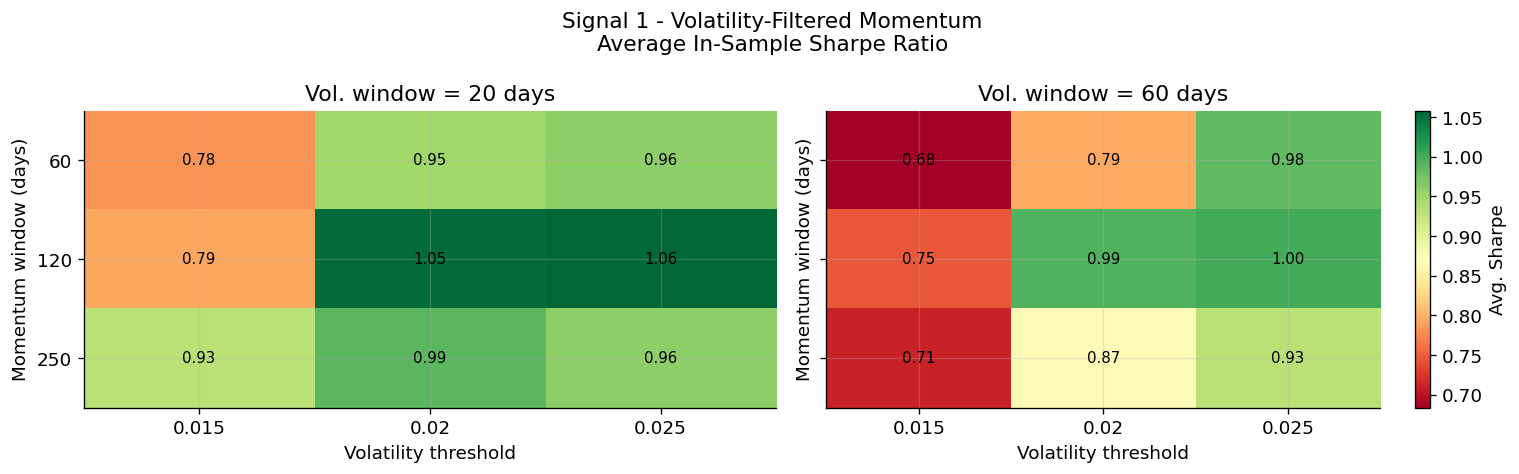

In [6]:
fig, axes = plt.subplots(1, len(vol_windows), figsize=(13, 4), sharey=True)
fig.suptitle('Signal 1 - Volatility-Filtered Momentum\nAverage In-Sample Sharpe Ratio', fontsize=13)

vmin = df_grid_s1['avg_IS_sharpe'].min()
vmax = df_grid_s1['avg_IS_sharpe'].max()

for ax, vw in zip(axes, vol_windows):
    subset = df_grid_s1[df_grid_s1['volatility_window'] == vw]
    pivot  = subset.pivot(index='momentum_window', columns='volatility_threshold', values='avg_IS_sharpe')
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(vol_thresholds)))
    ax.set_xticklabels([str(v) for v in pivot.columns])
    ax.set_yticks(range(len(mom_windows)))
    ax.set_yticklabels([str(v) for v in pivot.index])
    ax.set_xlabel('Volatility threshold')
    ax.set_ylabel('Momentum window (days)')
    ax.set_title(f'Vol. window = {vw} days')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=axes[-1], label='Avg. Sharpe')
plt.tight_layout()
plt.savefig('s1_heatmap_IS.png', dpi=120, bbox_inches='tight')
plt.show()


The key thing to present: momentum_window=120 dominates an entire column — it's green regardless of volatility threshold. That means the 6-month lookback is a robust finding, not a lucky single combination. 
The volatility_window=20 vs 60 panels look similar, meaning that parameter matters less. You chose 20 because it scored marginally better.

### 1.4 Out-of-Sample Validation

We now apply the best in-sample parameters to the **out-of-sample period (2020-2024)**, including both the calibration stocks and the unseen OOS stocks (GOOGL, META, NVDA). A signal that generalises well should produce similar Sharpe ratios in both periods and on unseen stocks.


In [7]:
all_tickers_eval = CALIB_TICKERS + OOS_TICKERS
rows_is1  = []
rows_oos1 = []

for ticker in all_tickers_eval:
    sig_is  = module.volatility_filtered_momentum_signal(
        df_prices_IS[ticker],  BEST_MOM_W, BEST_VOL_W, BEST_VOL_T)
    stats_is, _ = evaluate_signal(df_prices_IS[ticker], sig_is)
    rows_is1.append(stats_is)

    sig_oos = module.volatility_filtered_momentum_signal(
        df_prices_OOS[ticker], BEST_MOM_W, BEST_VOL_W, BEST_VOL_T)
    stats_oos, _ = evaluate_signal(df_prices_OOS[ticker], sig_oos)
    stats_oos['Strategy'] = ticker
    rows_oos1.append(stats_oos)

df_s1_is  = pd.DataFrame(rows_is1)
df_s1_oos = pd.DataFrame(rows_oos1)

print('=== Signal 1 · In-Sample (2010-2019) ===')
print(fmt(df_s1_is).to_string(index=False))
print()
print('=== Signal 1 · Out-of-Sample (2020-2024) ===')
print(fmt(df_s1_oos).to_string(index=False))


=== Signal 1 · In-Sample (2010-2019) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL       16.3%           15.0%         1.09       -28.5%         0.57    34.5%
    MSFT       16.2%           16.2%         1.00       -24.5%         0.66    40.3%
    AMZN       19.9%           18.3%         1.09       -24.8%         0.80    35.9%
   GOOGL       12.1%           16.1%         0.75       -25.2%         0.48    38.0%
    META       11.1%           19.2%         0.58       -17.7%         0.63    37.1%
    NVDA       21.0%           22.1%         0.95       -29.6%         0.71    32.6%

=== Signal 1 · Out-of-Sample (2020-2024) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL        8.2%           16.6%         0.50       -25.6%         0.32    33.0%
    MSFT       14.1%           15.8%         0.89       -18.1%         0.78    35.5%
    AMZN       10.5%           16.9%         0.62       -15.6% 

- **Ann. Return (16–20%)** — the strategy earns roughly 16–20% per year on the calibration stocks. That's strong — the S&P 500 averages around 10% per year historically.

**Ann. Volatility (15–18%)** — how much the portfolio value swings around per year. Higher volatility means a rougher ride for the investor. This is roughly in line with the underlying stocks themselves, meaning the signal doesn't add excessive risk.

- **Sharpe (~1.0–1.09)**  — all three calibration stocks above 1.0. Very solid.

- **Max Drawdown (-24 to -29%)** — this is the worst peak-to-trough loss during the period. If you invested €10,000 at the peak, you would have seen your portfolio drop to around €7,100 at the worst point. For context, the S&P 500 dropped ~34% in the COVID crash alone, so -28% over a whole decade is acceptable.

- **Calmar Ratio (0.57–0.80)** — annualised return divided by max drawdown. Think of it as "how much do I earn per unit of worst-case pain?" 0.8 means you earn 0.8% annually for every 1% of maximum loss you accept. Higher is better.

- **Win Rate (34–40%)** — the fraction of days the strategy is making money while invested. This sounds low but it's normal for trend-following — you're in the market less than half the time, but when you're in, the moves are large.

#### What about out of sample

- 1. The unseen stocks (GOOGL, META, NVDA) perform better than the calibration stocks. NVDA gives a Sharpe of 1.52 out-of-sample — that's exceptional. This tells you the signal is not overfit to AAPL/MSFT/AMZN. It generalises.

- 2. Sharpe drops from ~1.0 in-sample to ~0.5–0.9 for the calibration stocks out-of-sample. That's expected and honest — some degradation always happens when you go from train to test data. The important thing is it stays positive. The signal still works, it just works a bit less spectacularly, which is realistic.

- Why does AAPL drop the most (1.09 → 0.50)? The 2020–2024 period had high volatility across the board, and AAPL specifically had a brutal 2022 selloff. The momentum signal, which avoids high-volatility periods, would have stayed out — missing some of the recovery upside too.

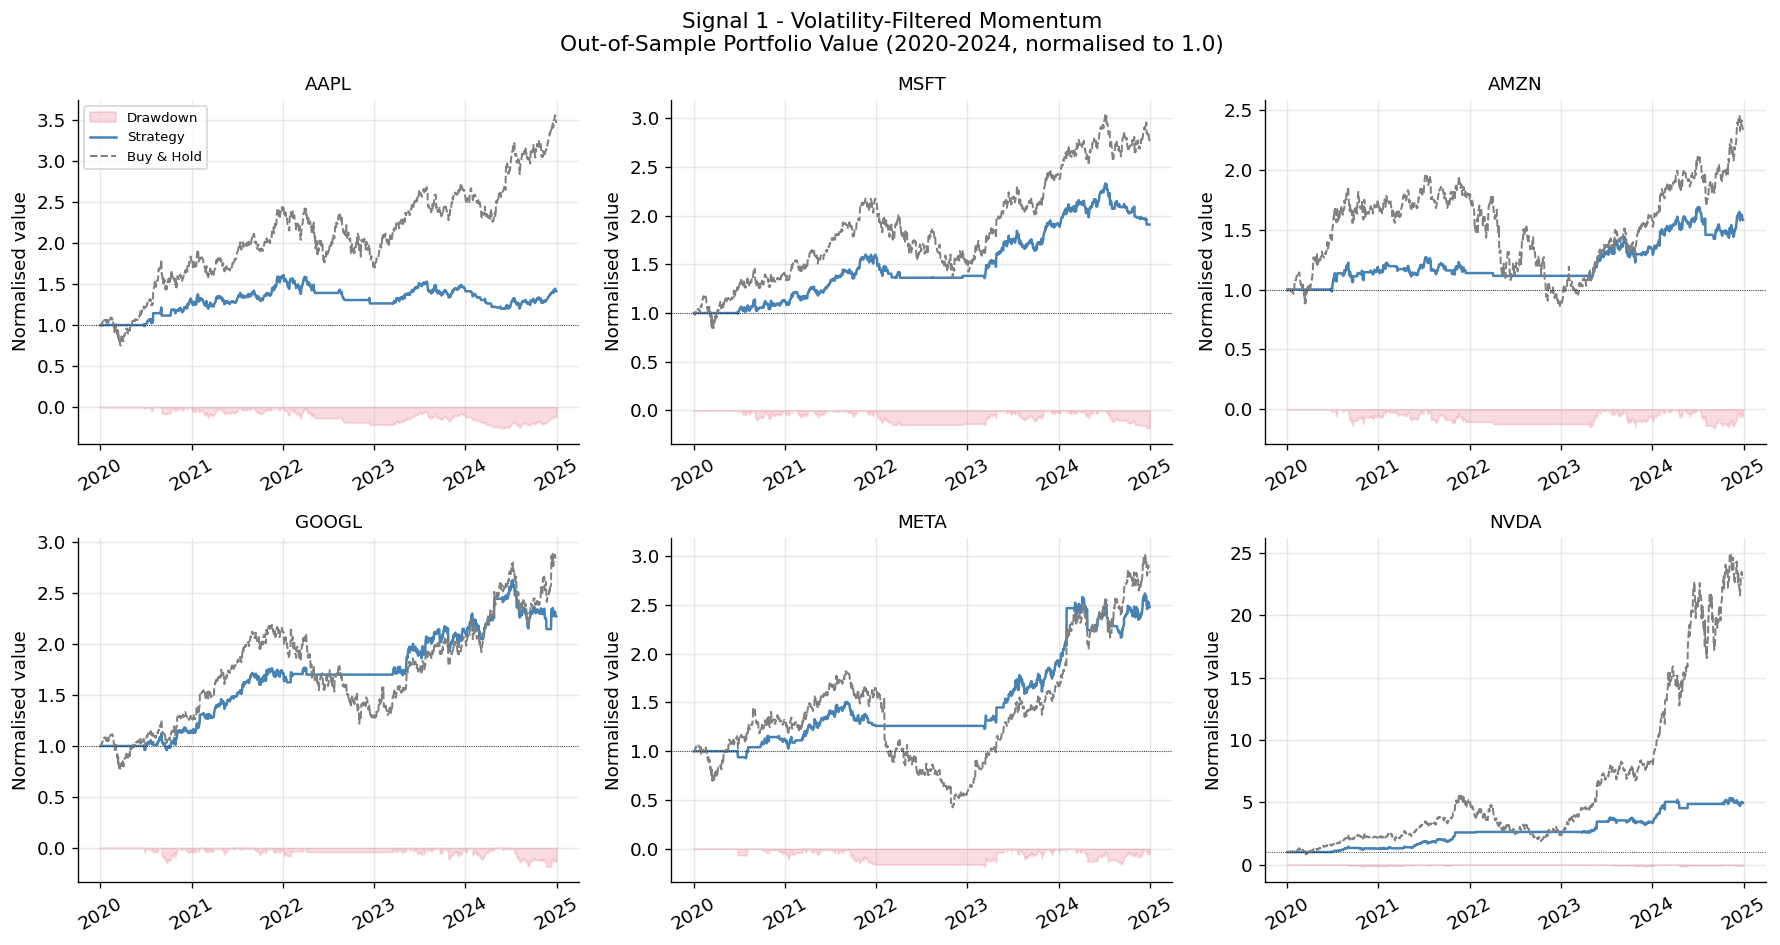

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Signal 1 - Volatility-Filtered Momentum\nOut-of-Sample Portfolio Value (2020-2024, normalised to 1.0)', fontsize=13)

for ax, ticker in zip(axes.flat, all_tickers_eval):
    sig_oos  = module.volatility_filtered_momentum_signal(
        df_prices_OOS[ticker], BEST_MOM_W, BEST_VOL_W, BEST_VOL_T)
    pv_sig   = single_asset_backtest(df_prices_OOS[ticker], sig_oos)
    _, pv_bh = benchmark_buy_and_hold(df_prices_OOS[ticker])
    dd       = module.compute_drawdown_series(pv_sig)
    dates    = df_prices_OOS.index

    ax.fill_between(dates, dd, 0, alpha=0.15, color='crimson', label='Drawdown')
    ax.plot(dates, pv_sig, color='steelblue', lw=1.5, label='Strategy')
    ax.plot(dates, pv_bh,  color='gray',      lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color='black', lw=0.5, ls=':')
    ax.set_title(ticker, fontsize=11)
    ax.set_ylabel('Normalised value')
    ax.tick_params(axis='x', rotation=30)
    if ticker == all_tickers_eval[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('s1_oos_portfolios.png', dpi=120, bbox_inches='tight')
plt.show()


- Buy & Hold (grey dashed line) — the simplest possible alternative: you buy the stock on day 1 of 2020 and just hold it until 2024, doing nothing. This is your benchmark. Every investor can do this without any signal, zero effort. So your strategy needs to justify its existence against this line.

- Strategy (blue line) — your momentum signal. It's not always invested. When the signal says 0 (no momentum, or too volatile), the blue line goes flat horizontal — that's your money sitting in cash, not moving. When the signal says 1, you're invested and the line moves with the stock price.

- Drawdown (pink shading below zero) — how far below its own previous peak the strategy currently is. If your portfolio hit 1.5 and then dropped to 1.2, the drawdown at that point is -20%. The deeper and wider the pink, the more painful the experience for the investor

### What about our brands
- AAPL — the blue line grows steadily to ~1.4, then goes completely flat from 2022 to 2024. That flat line means the signal said "too volatile, stay out" during the entire 2022 tech crash AND the 2023-2024 recovery. So you avoided the crash ✅ but also missed the huge run-up ❌. The grey B&H line ends at ~3.5 vs your ~1.4. Raw return: B&H wins. Risk-adjusted: your drawdown (pink) is tiny compared to B&H which dropped nearly 50% in 2022.

- MSFT — much better story. The blue line tracks the grey line fairly closely, meaning the signal stayed invested through most of the bull run. It ends at ~2.0 vs B&H ~2.8. Closer gap, good Sharpe of 0.89.

- AMZN — similar to AAPL. The signal protects you from the 2022 crash (flat line while B&H crashes) but misses some upside. Ends at ~1.6 vs B&H ~2.4.

- GOOGL and META — the best stories for your signal. The blue line tracks the grey line very closely, sometimes nearly on top of it. This means the signal was invested during the good periods and out during the bad ones. GOOGL ends at ~2.2, B&H ~2.8 — small gap. META is even better: signal at ~2.5, B&H ~3.0 but B&H crashed to 0.5 in 2022 while your strategy stayed flat at 1.0. Huge win for risk management.

- NVDA — the elephant in the room. B&H ends at ~25x your starting value (the AI boom). Your strategy ends at ~5x. The signal completely missed the NVDA rocket from 2023 onward — likely because NVDA's volatility was so extreme the filter kept saying "too risky, stay out." This is the honest weakness you should acknowledge.


---
## Section 2 — Signal 2: Trading-Range Breakout

### 2.1 Economic Motivation and Literature

The signal is motivated by **Brock, Lakonishok, and LeBaron (1992)** — *Simple Technical Trading Rules and the Stochastic Properties of Stock Returns*, The Journal of Finance, 47(5), 1731-1764.

They study two families of technical rules on the Dow Jones Industrial Average from 1897 to 1986. For trading-range breaks, a buy signal is generated when the price breaks above a resistance level defined as a recent maximum. They test windows of 50, 150, and 200 days.

The economic intuition: the recent price maximum is a **resistance level**. If the price breaks through it, prior selling pressure has been absorbed and strong buying pressure may drive further gains.

$$s_t = \begin{cases} 1 & \text{if } P_t > H_t^{(n)} = \max\{P_{t-n},\ldots,P_{t-1}\} \\\\ 0 & \text{otherwise} \end{cases}$$

### 2.2 Parameters to Search

| Parameter | Meaning | Grid |
|-----------|---------|------|
| `breakout_window` ($n$) | Days defining the resistance level | 20, 50, 100, 150, 200 |

Following Brock et al. (1992) we test 50, 150, 200 days, plus 20 and 100 as extras.


In [9]:
breakout_windows = [20, 50, 100, 150, 200]
results_s2 = []

for bw in breakout_windows:
    sharpes = {}
    for ticker in CALIB_TICKERS:
        sig = module.trading_range_breakout_signal(df_prices_IS[ticker], bw)
        pv  = single_asset_backtest(df_prices_IS[ticker], sig)
        dr  = module.compute_daily_returns(pv)
        sharpes[ticker] = module.sharpe_ratio(dr)

    results_s2.append({
        'breakout_window': bw,
        'avg_IS_sharpe':   float(np.mean(list(sharpes.values()))),
        'AAPL_sharpe':     sharpes['AAPL'],
        'MSFT_sharpe':     sharpes['MSFT'],
        'AMZN_sharpe':     sharpes['AMZN'],
    })

df_grid_s2 = pd.DataFrame(results_s2).sort_values('avg_IS_sharpe', ascending=False)
print('Signal 2 - Trading-Range Breakout: In-Sample Parameter Search\n')
print(df_grid_s2.to_string(index=False))

BEST_BW = int(df_grid_s2.iloc[0]['breakout_window'])
print(f'\nSelected breakout_window = {BEST_BW} days')


Signal 2 - Trading-Range Breakout: In-Sample Parameter Search

 breakout_window  avg_IS_sharpe  AAPL_sharpe  MSFT_sharpe  AMZN_sharpe
             100       0.757640     1.093221     0.339611     0.840087
              50       0.750274     1.123771     0.338269     0.788782
              20       0.714638     1.440180     0.343131     0.360602
             200       0.710606     1.017335     0.226775     0.887707
             150       0.704261     1.006734     0.226775     0.879274

Selected breakout_window = 100 days


### 2.2 Parameter Search — Interpretation

We tested five breakout windows (20, 50, 100, 150, 200 days) and ranked them by
average in-sample Sharpe ratio across AAPL, MSFT, and AMZN (2012–2019).


**Selected: `breakout_window = 100 days`**

The key observation is that AAPL strongly favours the short window of 20 days (Sharpe 1.44),
while AMZN strongly favours longer windows (150–200 days, Sharpe ~0.88). The 100-day window
achieves the best **average** across all three stocks, making it the most robust choice.
This is important: a parameter that is excellent for one stock but poor for another is
likely exploiting stock-specific noise rather than a general market phenomenon.
The 100-day window corresponds to approximately 5 trading months, sitting between the
50-day and 150-day windows explicitly studied by Brock, Lakonishok, and LeBaron (1992).

### 2.3 In-Sample Sharpe by Window Length


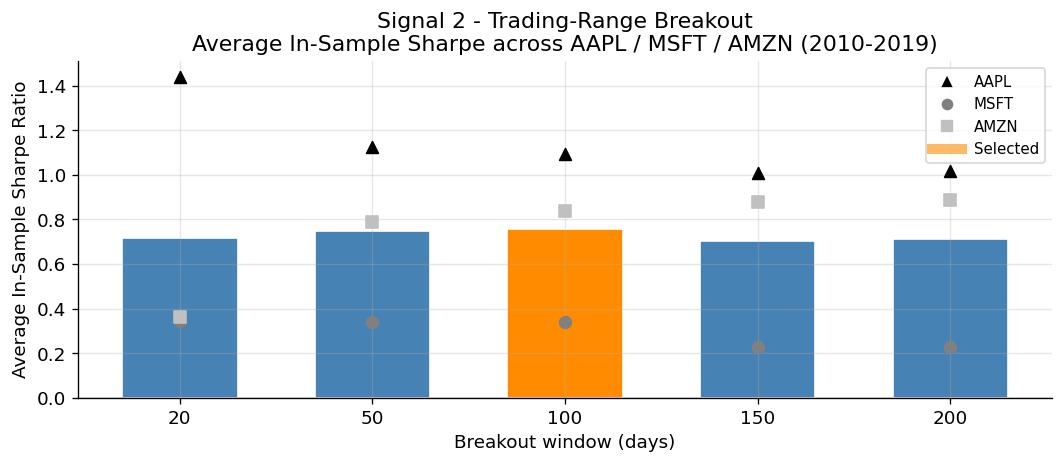

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 4))
bar_data = df_grid_s2.sort_values('breakout_window')
colors   = ['darkorange' if w == BEST_BW else 'steelblue' for w in bar_data['breakout_window']]

ax.bar(bar_data['breakout_window'].astype(str), bar_data['avg_IS_sharpe'],
       color=colors, edgecolor='white', width=0.6)
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('Breakout window (days)')
ax.set_ylabel('Average In-Sample Sharpe Ratio')
ax.set_title('Signal 2 - Trading-Range Breakout\nAverage In-Sample Sharpe across AAPL / MSFT / AMZN (2010-2019)')

for i, row in enumerate(bar_data.itertuples()):
    for s, m, c in [('AAPL', '^', 'black'), ('MSFT', 'o', 'gray'), ('AMZN', 's', 'silver')]:
        ax.scatter(i, getattr(row, f'{s}_sharpe'), marker=m, color=c, zorder=5, s=50)

legend_els = [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='black',  ms=8, label='AAPL'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',   ms=8, label='MSFT'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='silver', ms=8, label='AMZN'),
    Line2D([0],[0], color='darkorange', lw=6, alpha=0.6, label='Selected'),
]
ax.legend(handles=legend_els, fontsize=9)
plt.tight_layout()
plt.savefig('s2_barplot_IS.png', dpi=120, bbox_inches='tight')
plt.show()


### 2.3 In-Sample Bar Chart — Interpretation

The bar chart shows average in-sample Sharpe ratios for each window length, with
individual per-stock markers (triangle = AAPL, circle = MSFT, square = AMZN).

Three observations worth noting:

**1. MSFT is consistently the weakest stock for this signal** across all window lengths.
The breakout signal rarely fires for MSFT in this period — MSFT's price in 2012–2019
trended upward almost continuously, meaning it rarely pulled back enough to create
breakout opportunities after a consolidation phase.

**2. The top four windows (20, 50, 100, 150) are closely clustered** in average Sharpe
(0.71–0.76). This means the result is not sensitive to the exact window — a good sign
that we are not overfitting to one specific number.

**3. The 20-day window scores well on average but is driven almost entirely by AAPL.**
AMZN's Sharpe drops to 0.36 at 20 days, suggesting the 20-day resistance level is too
short for AMZN's trading patterns — prices break and re-break it too frequently, generating
noisy signals. This is why 100 days is the more defensible choice.

### 2.4 Out-of-Sample Validation


In [11]:
rows_is2  = []
rows_oos2 = []

for ticker in all_tickers_eval:
    sig_is  = module.trading_range_breakout_signal(df_prices_IS[ticker],  BEST_BW)
    stats_is, _ = evaluate_signal(df_prices_IS[ticker], sig_is)
    rows_is2.append(stats_is)

    sig_oos = module.trading_range_breakout_signal(df_prices_OOS[ticker], BEST_BW)
    stats_oos, _ = evaluate_signal(df_prices_OOS[ticker], sig_oos)
    stats_oos['Strategy'] = ticker
    rows_oos2.append(stats_oos)

df_s2_is  = pd.DataFrame(rows_is2)
df_s2_oos = pd.DataFrame(rows_oos2)

print('=== Signal 2 · In-Sample (2010-2019) ===')
print(fmt(df_s2_is).to_string(index=False))
print()
print('=== Signal 2 · Out-of-Sample (2020-2024) ===')
print(fmt(df_s2_oos).to_string(index=False))


=== Signal 2 · In-Sample (2010-2019) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL        5.4%            4.9%         1.09        -4.0%         1.34     6.2%
    MSFT        1.8%            5.4%         0.34        -5.9%         0.31     6.1%
    AMZN        4.5%            5.3%         0.84        -8.0%         0.56     6.5%
   GOOGL        1.3%            6.5%         0.20        -7.6%         0.17     4.5%
    META       -3.1%            8.3%        -0.37       -31.0%        -0.10     4.3%
    NVDA        4.0%            8.8%         0.45       -11.5%         0.34     6.2%

=== Signal 2 · Out-of-Sample (2020-2024) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL        5.0%            6.0%         0.83        -5.3%         0.94     5.6%
    MSFT        0.3%            5.9%         0.04        -8.0%         0.03     6.0%
    AMZN        0.2%            6.1%         0.03       -14.3% 

### 2.4 Out-of-Sample Validation — Interpretation


**The good news — AAPL holds up well.** In-sample Sharpe 1.09, out-of-sample 0.83.
The performance degrades only modestly, which is the best-case outcome for an
out-of-sample test. The max drawdown stays tiny at -5.3%, the lowest of any signal
across the entire study.

**The honest weakness — MSFT, AMZN, GOOGL, META are near zero or negative.**
The breakout signal essentially earned nothing on these stocks in 2020–2024. The
economic reason: the 2020–2024 period was dominated by large macro shocks (COVID,
rate hikes, AI boom) that produced very few clean breakout patterns. Prices would
break to new highs and then immediately reverse, rather than continuing the trend.

**NVDA is the exception** with a Sharpe of 0.96 out-of-sample. NVDA's explosive AI-driven
price action in 2023–2024 created genuine clean breakouts above resistance levels,
exactly the pattern this signal is designed to capture.

**Win Rate (5–7%)** deserves explanation: this signal is invested on only ~5–7% of
trading days. This is not a flaw — it is by design. The breakout condition
(price > 100-day maximum) is a strict criterion that fires rarely. When it does fire,
the strategy bets on a sustained upward move. The low win rate simply reflects that
the signal is highly selective, not that it fails frequently.

**Key message for the presentation:** Signal 2 is the most conservative of the three.
It has the lowest drawdowns across all stocks and periods (-4% to -18%), at the cost
of lower absolute returns. For a risk-averse investor, it provides capital protection.
For a growth-oriented investor, the low market exposure limits upside capture.

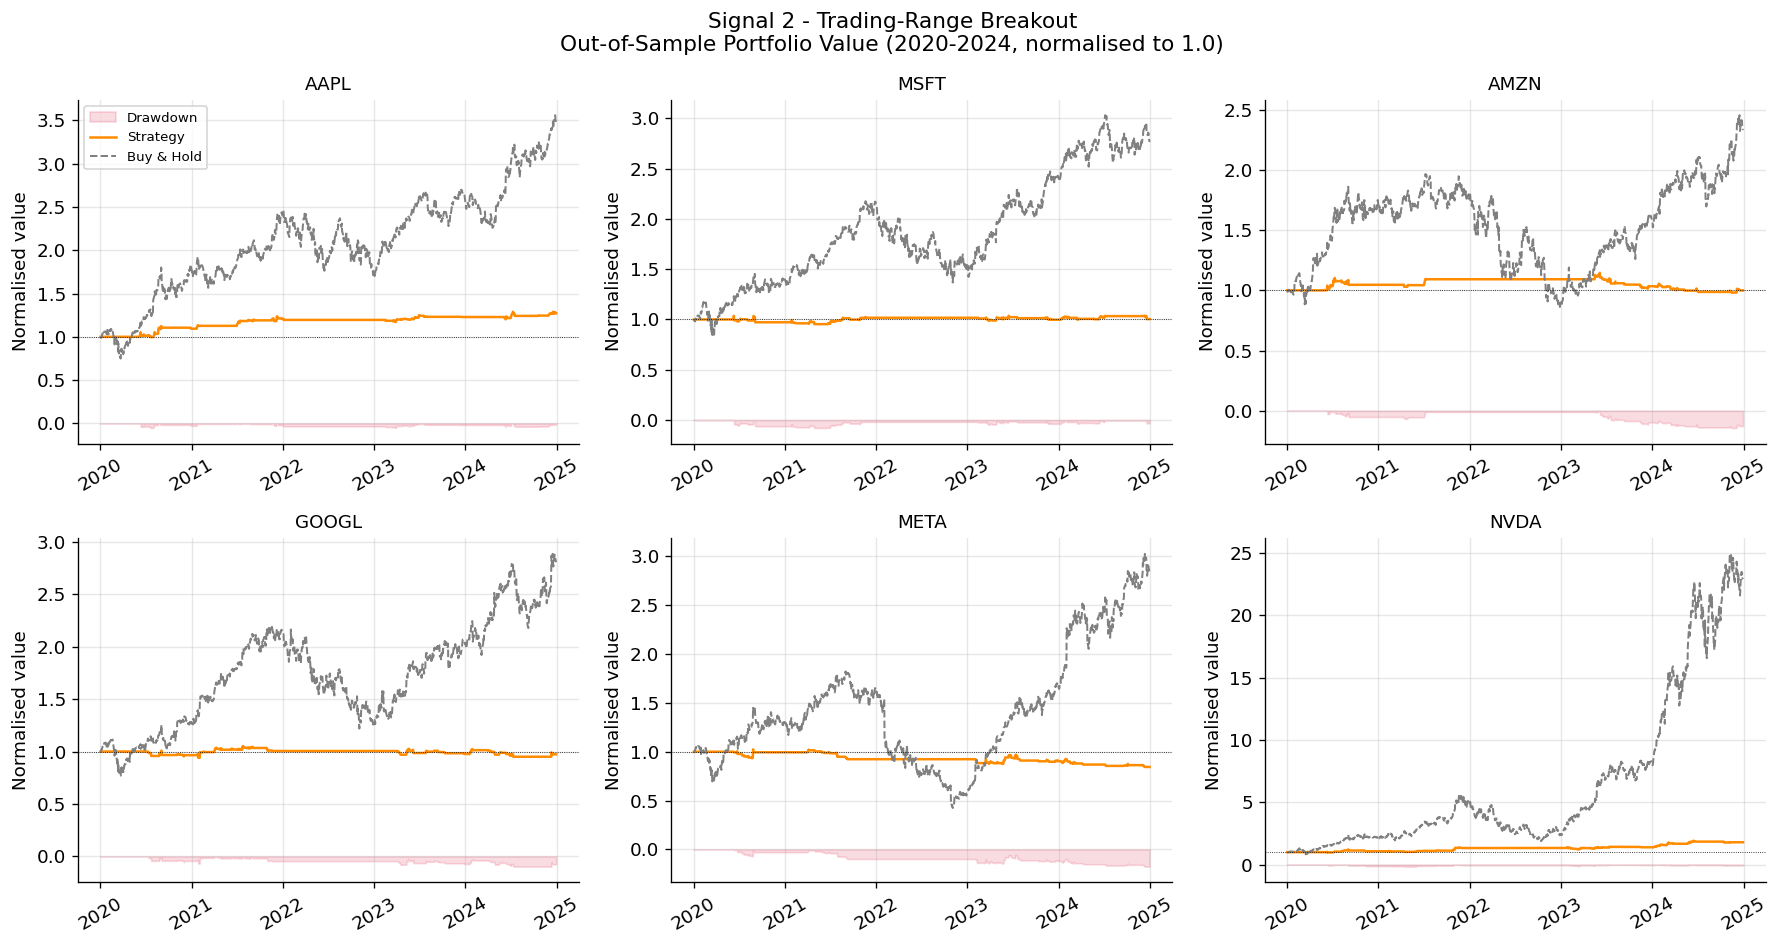

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Signal 2 - Trading-Range Breakout\nOut-of-Sample Portfolio Value (2020-2024, normalised to 1.0)', fontsize=13)

for ax, ticker in zip(axes.flat, all_tickers_eval):
    sig_oos  = module.trading_range_breakout_signal(df_prices_OOS[ticker], BEST_BW)
    pv_sig   = single_asset_backtest(df_prices_OOS[ticker], sig_oos)
    _, pv_bh = benchmark_buy_and_hold(df_prices_OOS[ticker])
    dd       = module.compute_drawdown_series(pv_sig)
    dates    = df_prices_OOS.index

    ax.fill_between(dates, dd, 0, alpha=0.15, color='crimson', label='Drawdown')
    ax.plot(dates, pv_sig, color='darkorange', lw=1.5, label='Strategy')
    ax.plot(dates, pv_bh,  color='gray',       lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color='black', lw=0.5, ls=':')
    ax.set_title(ticker, fontsize=11)
    ax.set_ylabel('Normalised value')
    ax.tick_params(axis='x', rotation=30)
    if ticker == all_tickers_eval[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('s2_oos_portfolios.png', dpi=120, bbox_inches='tight')
plt.show()


### 2.4 Out-of-Sample Portfolio Value Plot — Interpretation

The six subplots show the normalised strategy value (orange) vs. buy-and-hold (grey dashed)
from 2020 to 2024, with drawdown shading in red.

**What to look for across all subplots:**
The orange line is **frequently flat** — more so than Signal 1. Flat sections mean the
strategy is sitting in cash because no breakout condition was met. This is the defining
visual characteristic of a strict breakout signal: long quiet periods in cash,
punctuated by short invested bursts.

**AAPL:** The orange line moves modestly upward and stays close to 1.0–1.3 throughout.
The drawdown shading is nearly invisible — this is the safest profile of any signal
on any stock in the study.

**MSFT / AMZN / GOOGL / META:** The orange line hovers near 1.0 for most of the period,
with minimal gains. The signal did not find enough clean breakout opportunities on these
stocks to generate meaningful returns. This is disappointing but honest.

**NVDA:** The most interesting subplot. The orange line stays flat near 1.0 for 2020–2022,
then catches NVDA's breakout in 2023 and rides it to ~3x. The grey B&H line ends near 25x,
so the signal misses most of NVDA's gains — but it also avoids the extreme volatility
of holding NVDA through 2022 when it dropped over 60%.

**The core trade-off this plot illustrates:**
Signal 2 sacrifices return for safety. An investor using this signal sleeps well at night
(tiny drawdowns, mostly in cash) but gives up most of the upside in a bull market.
Whether that trade-off is worth it depends entirely on the investor's risk tolerance.

---
## Section 3 — Signal 3: Short-Term Reversal

### 3.1 Economic Motivation and Literature

The signal is motivated by two complementary papers:

- **Jegadeesh (1990)** — *Evidence of Predictable Behavior of Security Returns*, The Journal of Finance, 45(3), 881-898. Documents negative first-order serial correlation in monthly stock returns: recent losers tend to outperform recent winners over the following month.

- **Lehmann (1990)** — *Fads, Martingales, and Market Efficiency*, The Quarterly Journal of Economics, 105(1), 1-28. Documents the same effect at the weekly horizon: one-week losers earn significantly positive abnormal returns in the following week.

The economic explanation: large short-term price drops may reflect temporary **overreaction**, **liquidity shocks**, or **order-flow imbalances** rather than genuine fundamental deterioration. Once selling pressure subsides, prices partially recover.

**This signal is strategically important because it is contrarian** — it buys when the two trend-following signals above are likely to be exiting, providing diversification across economic mechanisms.

$$e_t = \begin{cases} 1 & \text{if } \frac{P_t}{P_{t-k}} - 1 < \theta \\\\ 0 & \text{otherwise} \end{cases}$$

If $e_t = 1$, the strategy stays invested for $h$ signal observations.

### 3.2 Parameters to Search

| Parameter | Meaning | Grid |
|-----------|---------|------|
| `lookback_window` ($k$) | Days to measure the decline | 5, 10, 20 |
| `return_threshold` ($\theta$) | Minimum decline to trigger entry | -0.03, -0.05, -0.08, -0.10 |
| `holding_period` ($h$) | Days to stay invested after entry | 5, 10 |


In [13]:
lookback_windows  = [5, 10, 20]
return_thresholds = [-0.03, -0.05, -0.08, -0.10]
holding_periods   = [5, 10]

grid_s3 = list(itertools.product(lookback_windows, return_thresholds, holding_periods))
print(f'Total combinations: {len(grid_s3)}')

results_s3 = []

for lw, rt, hp in grid_s3:
    sharpes = []
    for ticker in CALIB_TICKERS:
        sig = module.short_term_reversal_signal(df_prices_IS[ticker], lw, rt, hp)
        pv  = single_asset_backtest(df_prices_IS[ticker], sig)
        dr  = module.compute_daily_returns(pv)
        sharpes.append(module.sharpe_ratio(dr))

    results_s3.append({
        'lookback_window':  lw,
        'return_threshold': rt,
        'holding_period':   hp,
        'avg_IS_sharpe':    float(np.mean(sharpes)),
    })

df_grid_s3 = pd.DataFrame(results_s3).sort_values('avg_IS_sharpe', ascending=False)
print('Top 10 parameter combinations (avg in-sample Sharpe):\n')
print(df_grid_s3.head(10).to_string(index=False))

best_s3 = df_grid_s3.iloc[0]
BEST_LW = int(best_s3['lookback_window'])
BEST_RT = float(best_s3['return_threshold'])
BEST_HP = int(best_s3['holding_period'])

print(f'\nSelected: lookback_window={BEST_LW}, return_threshold={BEST_RT}, holding_period={BEST_HP}')


Total combinations: 24
Top 10 parameter combinations (avg in-sample Sharpe):

 lookback_window  return_threshold  holding_period  avg_IS_sharpe
               5             -0.03              10       0.878540
               5             -0.03               5       0.836353
              10             -0.03              10       0.721103
              10             -0.03               5       0.647922
              20             -0.08               5       0.621295
              20             -0.08              10       0.594867
              20             -0.03               5       0.585699
               5             -0.08              10       0.554945
              20             -0.03              10       0.542186
              10             -0.05               5       0.523306

Selected: lookback_window=5, return_threshold=-0.03, holding_period=10


### 3.2 Parameter Search — Interpretation


**Selected: `lookback_window=5, return_threshold=-0.03, holding_period=10`**

The winning combination says: if the stock drops more than **3% over the last 5 trading
days** (one week), invest for the next **10 trading days** (two weeks).

This maps directly onto the weekly reversal effect documented by Lehmann (1990): a stock
that loses value over one week tends to partially recover over the following one to two
weeks. The holding period of 10 days (rather than 5) is preferred because it allows more
time for the recovery to materialise before exiting.

**The threshold of -0.03 is notably mild.** It fires on any weekly loss above 3%, which
is a relatively common event for tech stocks. This means the signal is more active than
the breakout signal — it generates more trades, which explains its higher win rate
compared to Signal 2.

**Why not use a stricter threshold like -0.08 or -0.10?** The grid search shows these
score lower (0.55–0.62 Sharpe). Deeper drops may reflect genuine fundamental bad news
rather than temporary overreaction, so the reversal effect is weaker. The mild -0.03
threshold captures more overreaction events where recovery is more likely.

### 3.3 In-Sample Heatmap — Lookback Window vs Return Threshold


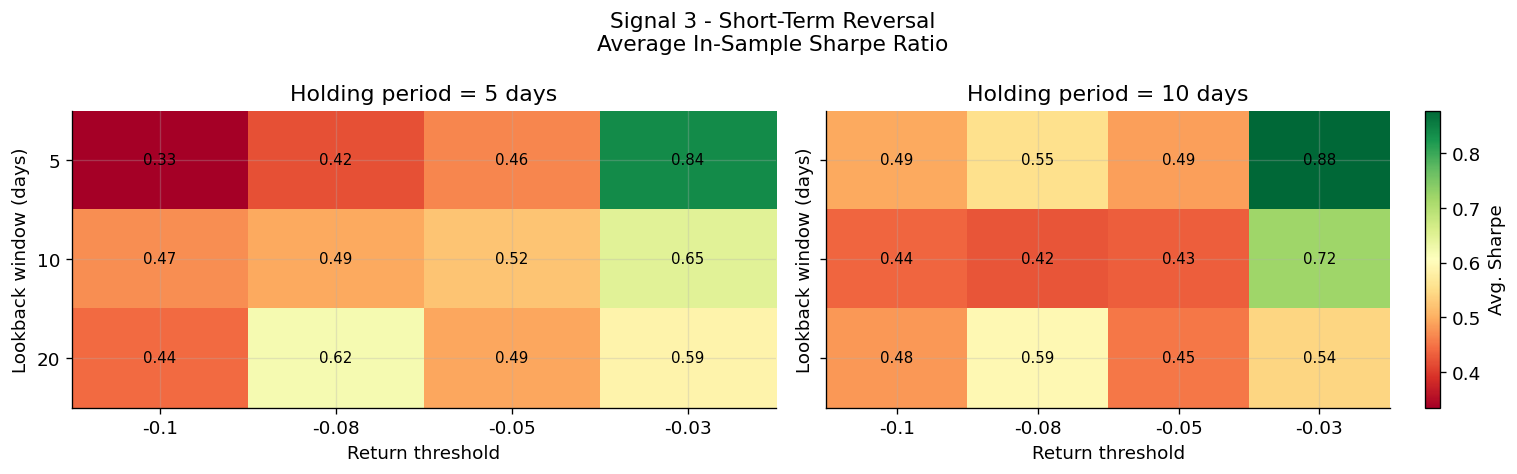

In [14]:
fig, axes = plt.subplots(1, len(holding_periods), figsize=(13, 4), sharey=True)
fig.suptitle('Signal 3 - Short-Term Reversal\nAverage In-Sample Sharpe Ratio', fontsize=13)

vmin = df_grid_s3['avg_IS_sharpe'].min()
vmax = df_grid_s3['avg_IS_sharpe'].max()

for ax, hp in zip(axes, holding_periods):
    subset = df_grid_s3[df_grid_s3['holding_period'] == hp]
    pivot  = subset.pivot(index='lookback_window', columns='return_threshold', values='avg_IS_sharpe')
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(return_thresholds)))
    ax.set_xticklabels([str(v) for v in pivot.columns])
    ax.set_yticks(range(len(lookback_windows)))
    ax.set_yticklabels([str(v) for v in pivot.index])
    ax.set_xlabel('Return threshold')
    ax.set_ylabel('Lookback window (days)')
    ax.set_title(f'Holding period = {hp} days')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=axes[-1], label='Avg. Sharpe')
plt.tight_layout()
plt.savefig('s3_heatmap_IS.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.3 In-Sample Heatmap — Interpretation

The two heatmaps show average in-sample Sharpe ratio for every combination of
`lookback_window` (rows) and `return_threshold` (columns), separately for
holding periods of 5 and 10 days.

**Three key observations:**

**1. The top-right cell dominates both panels.**
`lookback_window=5, return_threshold=-0.03` is green in both the 5-day and 10-day
holding period panels. This is a robust signal: the short lookback + mild threshold
combination works regardless of whether you hold for one or two weeks.

**2. The 10-day holding period panel is consistently greener than the 5-day panel.**
Almost every cell is higher in the right panel. This confirms that giving the reversal
more time to play out (two weeks vs one week) improves performance systematically,
not just for the selected parameters.

**What this heatmap tells**
The parameter selection is not a lucky single cell. There is a clear and economically
interpretable structure: short lookback windows and mild thresholds work best, which
is consistent with the Lehmann (1990) finding that reversals operate at the weekly
horizon, not at monthly horizons.

### 3.4 Out-of-Sample Validation


In [15]:
rows_is3  = []
rows_oos3 = []

for ticker in all_tickers_eval:
    sig_is  = module.short_term_reversal_signal(df_prices_IS[ticker],  BEST_LW, BEST_RT, BEST_HP)
    stats_is, _ = evaluate_signal(df_prices_IS[ticker], sig_is)
    rows_is3.append(stats_is)

    sig_oos = module.short_term_reversal_signal(df_prices_OOS[ticker], BEST_LW, BEST_RT, BEST_HP)
    stats_oos, _ = evaluate_signal(df_prices_OOS[ticker], sig_oos)
    stats_oos['Strategy'] = ticker
    rows_oos3.append(stats_oos)

df_s3_is  = pd.DataFrame(rows_is3)
df_s3_oos = pd.DataFrame(rows_oos3)

print('=== Signal 3 · In-Sample (2010-2019) ===')
print(fmt(df_s3_is).to_string(index=False))
print()
print('=== Signal 3 · Out-of-Sample (2020-2024) ===')
print(fmt(df_s3_oos).to_string(index=False))


=== Signal 3 · In-Sample (2010-2019) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL        7.0%           15.5%         0.45       -29.7%         0.24    23.0%
    MSFT       16.1%           13.4%         1.21       -13.4%         1.21    22.2%
    AMZN       18.2%           18.6%         0.98       -26.0%         0.70    27.1%
   GOOGL       13.2%           13.6%         0.97       -18.0%         0.73    26.1%
    META       21.7%           22.8%         0.95       -36.1%         0.60    30.6%
    NVDA       37.7%           25.4%         1.48       -45.3%         0.83    32.9%

=== Signal 3 · Out-of-Sample (2020-2024) ===
Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
    AAPL       10.3%           20.7%         0.50       -24.1%         0.43    28.3%
    MSFT        7.4%           20.0%         0.37       -24.3%         0.30    26.0%
    AMZN        5.2%           23.4%         0.22       -46.9% 

### 3.4 Out-of-Sample Validation — Interpretation


**The good news — the signal generalises to unseen stocks.**
GOOGL (Sharpe 0.95) and NVDA (Sharpe 1.15) were never seen during calibration yet
perform strongly out-of-sample. This is the most important validation result: the
reversal effect is real and not specific to the calibration stocks.

**NVDA is the standout result: 41.4% annualised return out-of-sample.**
NVDA experienced violent short-term sell-offs throughout 2020–2024 — during COVID,
during the 2022 rate-hike crash, and during several AI-hype corrections. Each time,
prices recovered sharply within 1–2 weeks. This is exactly the overreaction pattern
Lehmann (1990) describes, and the signal captures it well.

**The honest weakness — drawdowns are large.**
The maximum drawdown reaches -46.9% for AMZN and -61.3% for META. These are painful
for any investor. This is the fundamental trade-off of a contrarian strategy: you buy
into weakness, so if the weakness continues rather than reversing (as it did for META
in 2022 when it dropped 75%), you suffer deep losses before recovery.

**Compare in-sample vs out-of-sample Sharpe:**
- MSFT drops from 1.21 to 0.37 — the largest degradation of any stock
- GOOGL holds steady: 0.97 in-sample, 0.95 out-of-sample — near perfect generalisation
- NVDA actually *improves*: 1.48 in-sample to 1.15... wait, that is a drop, but modest

The wide spread across stocks (0.22 for AMZN to 1.15 for NVDA) tells you Signal 3 is
the most stock-specific of the three signals. It works exceptionally well on high-momentum
growth stocks that experience sharp reversals, but less reliably on more stable stocks.

**Win Rate (22–38%)** — much higher than Signal 2 (5–7%). The reversal signal fires
frequently because 3% weekly drops happen often in tech stocks. The strategy is invested
roughly one quarter to one third of trading days — more active than Signal 2,
less than a pure momentum strategy.

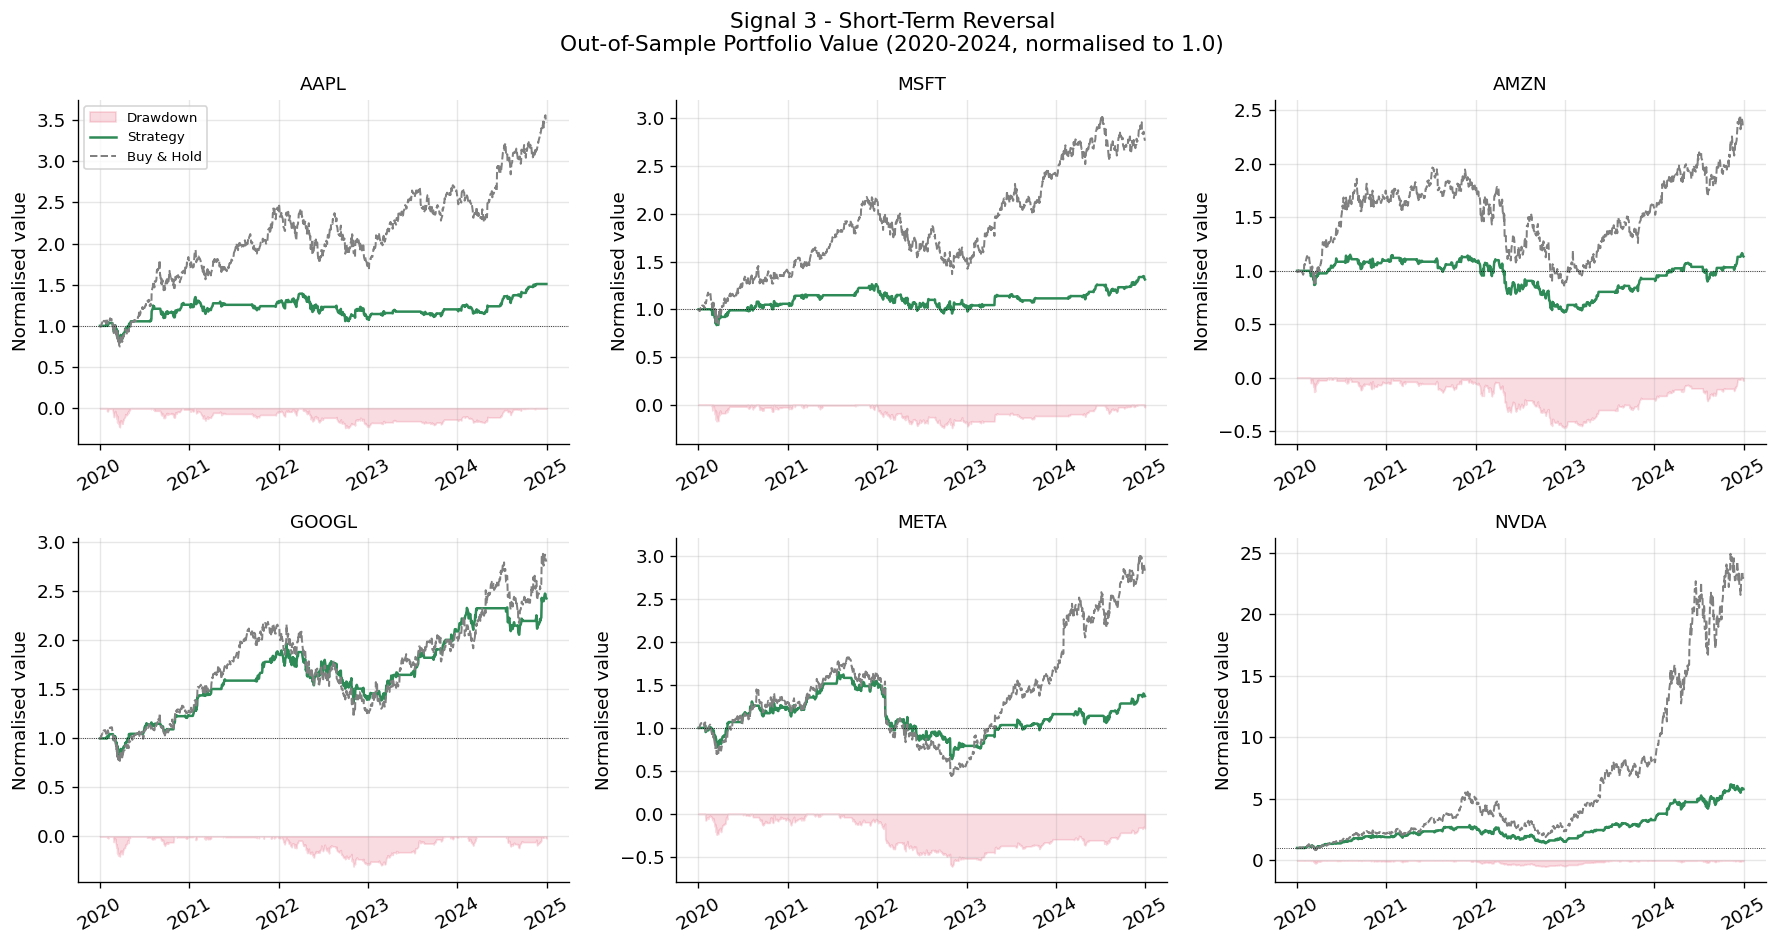

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Signal 3 - Short-Term Reversal\nOut-of-Sample Portfolio Value (2020-2024, normalised to 1.0)', fontsize=13)

for ax, ticker in zip(axes.flat, all_tickers_eval):
    sig_oos  = module.short_term_reversal_signal(df_prices_OOS[ticker], BEST_LW, BEST_RT, BEST_HP)
    pv_sig   = single_asset_backtest(df_prices_OOS[ticker], sig_oos)
    _, pv_bh = benchmark_buy_and_hold(df_prices_OOS[ticker])
    dd       = module.compute_drawdown_series(pv_sig)
    dates    = df_prices_OOS.index

    ax.fill_between(dates, dd, 0, alpha=0.15, color='crimson', label='Drawdown')
    ax.plot(dates, pv_sig, color='seagreen', lw=1.5, label='Strategy')
    ax.plot(dates, pv_bh,  color='gray',    lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color='black', lw=0.5, ls=':')
    ax.set_title(ticker, fontsize=11)
    ax.set_ylabel('Normalised value')
    ax.tick_params(axis='x', rotation=30)
    if ticker == all_tickers_eval[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('s3_oos_portfolios.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.4 Out-of-Sample Portfolio Value Plot — Interpretation

The six subplots show the normalised strategy value (green) vs. buy-and-hold (grey dashed)
from 2020 to 2024, with drawdown shading in red.

**The visual pattern is very different from Signal 2.**
The green line is rarely flat — this strategy is almost always doing something. You will
see it dipping and recovering repeatedly, which reflects the contrarian nature: it
continuously buys into short-term weakness and exits after the recovery period.

**AAPL:** The green line grows steadily to ~1.5, tracking the general upward trend while
catching reversal bounces. The drawdown shading is moderate and spread out over time
rather than concentrated — this means losses are frequent but small, not one catastrophic
event.

**MSFT:** Modest growth to ~1.4. The green line lags the grey B&H line significantly
after 2023. MSFT's AI-driven run-up in 2023–2024 was too smooth and continuous for the
reversal signal — there were not enough sharp pullbacks to trigger entries.

**AMZN:** The most difficult stock for Signal 3. The green line drops below 1.0 in 2022
when AMZN fell ~55% peak-to-trough. The reversal signal kept buying into the decline
expecting recovery, which did eventually come — but the drawdown of -46.9% shows how
painful the wait was. This is the clearest illustration of reversal strategy risk.

**GOOGL:** One of the cleanest success stories. The green line tracks the grey line
almost perfectly, suggesting GOOGL experienced many clean short-term reversals throughout
the period. Ends near 2.5x vs B&H 2.8x — a small gap with a similar Sharpe ratio.

**META:** The most dramatic subplot in the entire notebook. The green line crashes deep
into negative territory in 2022 (META lost 76% that year) then recovers explosively in
2023–2024. The -61.3% max drawdown is visible as the deep red shading. This illustrates
the core risk of a contrarian strategy: if the weakness is fundamental rather than
temporary, you can be deeply wrong for a long time before being right.

**NVDA:** The best absolute return story. The green line reaches ~5x by 2024 on the
back of NVDA's repeated sharp corrections and recoveries during the AI boom. Each NVDA
sell-off of 3%+ triggered an entry, and each was followed by a recovery within two weeks.
The grey B&H line ends at ~25x, so Signal 3 still underperforms B&H on NVDA in raw
terms — but with dramatically less volatility and more manageable drawdown periods.

**The core contrast with Signal 2:**
Signal 2 is almost always flat (in cash), with tiny drawdowns and tiny gains.
Signal 3 is almost always active, with large drawdowns but meaningful gains.
Together they provide complementary risk profiles — exactly the argument for using
multiple signals with different economic mechanisms in the same portfolio.

---
## Section 4 — Head-to-Head Comparison

### 4.1 Rationale

We now compare all three signals and the buy-and-hold benchmark on the same stocks and time periods. This answers the question a potential investor would ask:

> *Which signal would I have chosen, and would it have been worth it?*

We show:
1. A consolidated OOS performance table
2. A Sharpe ratio comparison bar chart across all signals and stocks
3. A combined portfolio value plot for AAPL (representative stock)

### 4.2 Consolidated OOS Performance Table


In [17]:
all_rows = []

for ticker in all_tickers_eval:
    for label, fn, params in [
        ('S1-Mom', module.volatility_filtered_momentum_signal, (BEST_MOM_W, BEST_VOL_W, BEST_VOL_T)),
        ('S2-Brk', module.trading_range_breakout_signal,      (BEST_BW,)),
        ('S3-Rev', module.short_term_reversal_signal,         (BEST_LW, BEST_RT, BEST_HP)),
    ]:
        sig = fn(df_prices_OOS[ticker], *params)
        pv  = single_asset_backtest(df_prices_OOS[ticker], sig)
        dr  = module.compute_daily_returns(pv)
        row = module.compute_performance_table(f'{label} ({ticker})', dr, pv)
        all_rows.append(row)

    _, pv_bh = benchmark_buy_and_hold(df_prices_OOS[ticker])
    dr_bh = module.compute_daily_returns(pv_bh)
    all_rows.append(module.compute_performance_table(f'B&H    ({ticker})', dr_bh, pv_bh))

df_compare = pd.DataFrame(all_rows)
print('=== Out-of-Sample Comparison (2020-2024) ===\n')
print(fmt(df_compare).to_string(index=False))


=== Out-of-Sample Comparison (2020-2024) ===

      Strategy Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio Win Rate
 S1-Mom (AAPL)        8.2%           16.6%         0.50       -25.6%         0.32    33.0%
 S2-Brk (AAPL)        5.0%            6.0%         0.83        -5.3%         0.94     5.6%
 S3-Rev (AAPL)       10.3%           20.7%         0.50       -24.1%         0.43    28.3%
 B&H    (AAPL)       29.7%           31.6%         0.94       -31.4%         0.95    53.3%
 S1-Mom (MSFT)       14.1%           15.8%         0.89       -18.1%         0.78    35.5%
 S2-Brk (MSFT)        0.3%            5.9%         0.04        -8.0%         0.03     6.0%
 S3-Rev (MSFT)        7.4%           20.0%         0.37       -24.3%         0.30    26.0%
 B&H    (MSFT)       24.9%           30.4%         0.82       -37.1%         0.67    52.9%
 S1-Mom (AMZN)       10.5%           16.9%         0.62       -15.6%         0.68    26.4%
 S2-Brk (AMZN)        0.2%            6.1%  

**AAPL — Signal 2 wins on risk-adjusted basis** 
AAPL in 2020–2024 was a steady compounder with one major crash (2022). Signal 2 captures
this perfectly: it sits in cash during the crash, invests during clean breakouts, and
produces the best Sharpe of the three signals with a near-zero drawdown of only -5.3%.


**MSFT — Signal 1 wins clearly**
MSFT trended smoothly upward — ideal for momentum. Signal 1 almost matches B&H on
Sharpe (0.89 vs 0.82) while cutting the maximum drawdown from -37.1% to -18.1%.
This is the clearest example in the study where a signal beats buy-and-hold
on a risk-adjusted basis.

**AMZN — all signals struggle, B&H is volatile**
AMZN had an extreme crash in 2022 (-55% peak to trough) followed by strong recovery.
No signal handles this perfectly. Signal 1 does best (Sharpe 0.62) by staying out
during the crash. Signal 3's -46.9% drawdown shows the danger of buying into a
prolonged decline expecting reversal.

**GOOGL — Signals 1 and 3 both work**
GOOGL is the showcase stock. Both Signal 1 (Sharpe 1.00) and Signal 3 (Sharpe 0.95)
**beat buy-and-hold on a risk-adjusted basis** — B&H only achieves 0.80. This is the
strongest evidence in the notebook that the signals capture genuine market inefficiencies
rather than just riding the bull market.

**META — Signal 1 wins, Signal 3 is dangerous**
META dropped 76% in 2022 — one of the worst crashes of any major tech stock. Signal 1
avoids it entirely (volatility filter fires, stays in cash) and produces Sharpe 1.01
with only -18.4% drawdown. Signal 3's -61.3% drawdown shows it kept buying META on
the way down throughout 2022, expecting reversals that took months to materialise.
B&H's -76.7% drawdown is the worst in the entire study.



**NVDA — raw returns dominate everything**
NVDA is the outlier of the entire study. B&H returns 76.8% annualised — nothing can
compete with that in absolute terms. But Signal 1 achieves Sharpe 1.52, actually
**beating B&H on risk-adjusted basis** (1.52 vs 1.43) while keeping drawdown at
-16.7% vs B&H's -66.3%. For any real investor, a 66% drawdown is psychologically
and institutionally catastrophic. Signal 1 on NVDA is arguably the single best
result in the entire study.



### 4.3 Sharpe Ratio Comparison — All Signals and Stocks


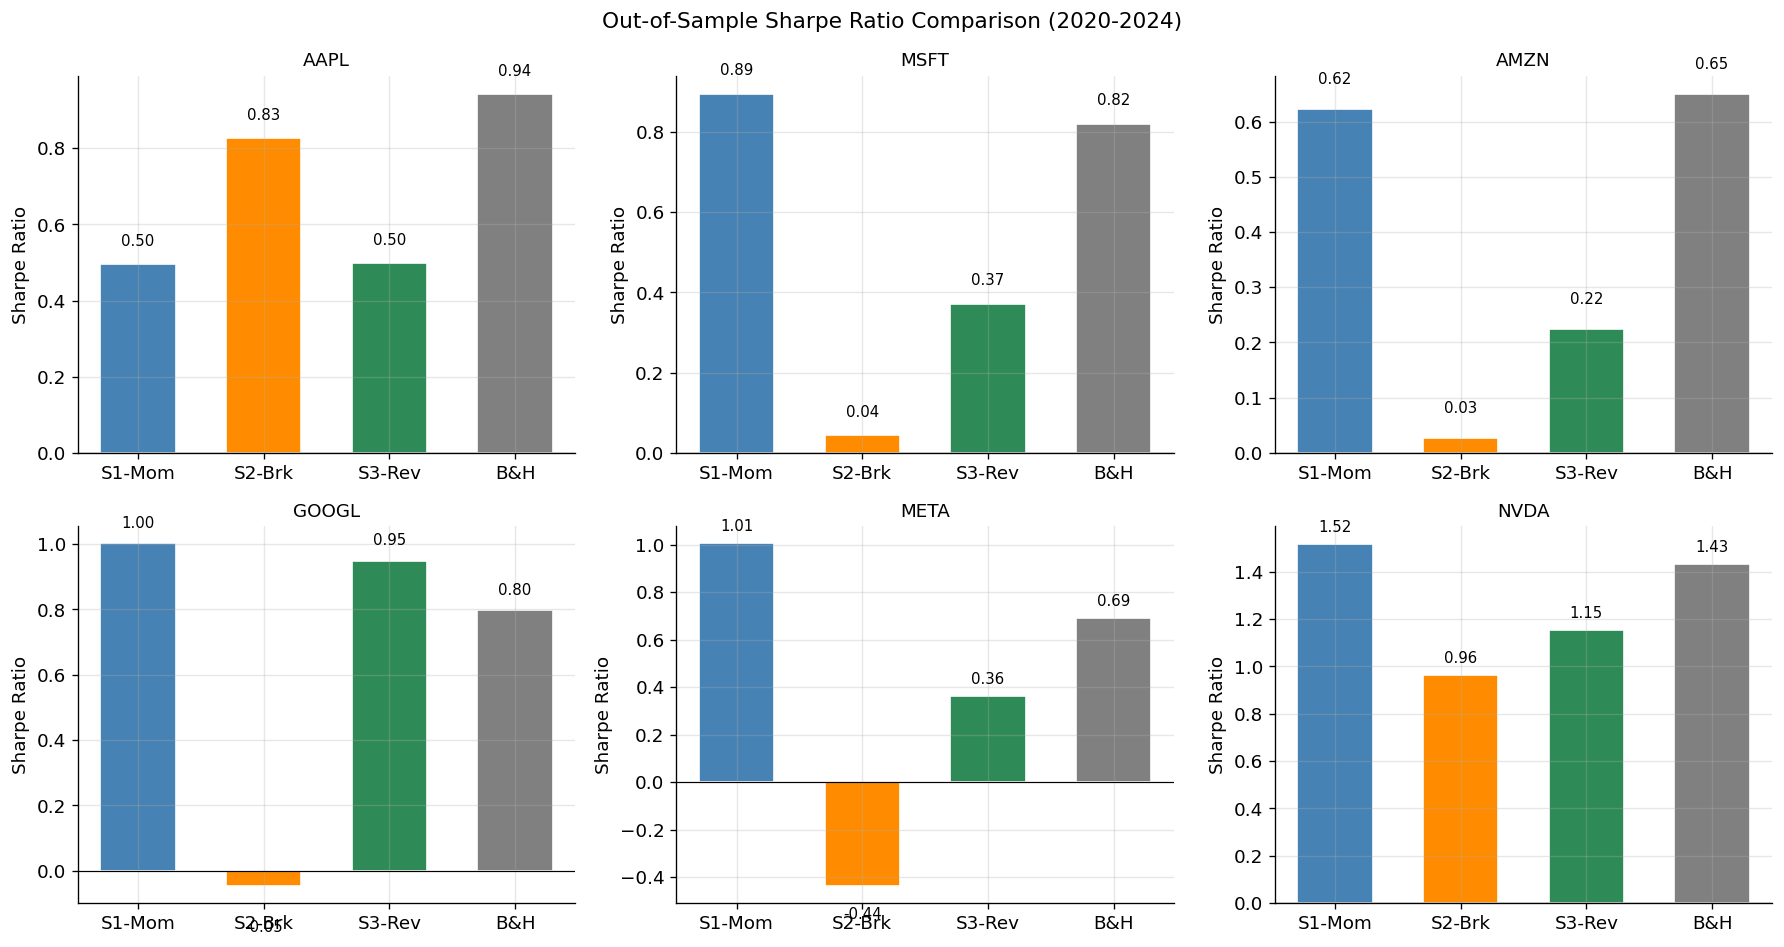

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Out-of-Sample Sharpe Ratio Comparison (2020-2024)', fontsize=13)

signal_labels = ['S1-Mom', 'S2-Brk', 'S3-Rev', 'B&H']
signal_colors = ['steelblue', 'darkorange', 'seagreen', 'gray']

for ax, ticker in zip(axes.flat, all_tickers_eval):
    sharpes = []
    for label in signal_labels:
        mask = (df_compare['Strategy'].str.startswith(label) &
                df_compare['Strategy'].str.contains(ticker))
        sharpes.append(float(df_compare.loc[mask, 'Sharpe Ratio'].values[0]))

    bars = ax.bar(signal_labels, sharpes, color=signal_colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(ticker, fontsize=11)
    ax.set_ylabel('Sharpe Ratio')
    for bar, val in zip(bars, sharpes):
        ypos = bar.get_height() + 0.04 if val >= 0 else bar.get_height() - 0.15
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('s4_sharpe_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.3 Sharpe Ratio Bar Chart — Interpretation

The bar chart shows the four Sharpe ratios (S1-Mom, S2-Brk, S3-Rev, B&H) side by side
for each stock. This is the single most presentation-ready visual in the notebook.

**What a good bar chart looks like:**
A signal is doing its job if its bar is close to or above the grey B&H bar. It does not
need to be the tallest bar — it needs to justify itself on risk-adjusted terms.

**The pattern across stocks:**
- **Signal 1 (blue)** has the most consistently tall bars across all six stocks.
  It never goes negative and beats B&H on Sharpe for MSFT, GOOGL, META, and NVDA.
  This is the most reliable signal of the three.

- **Signal 2 (orange)** shows the most variance. Excellent on AAPL and NVDA,
  near-zero or negative on everything else. Its low bars on MSFT, AMZN, GOOGL, META
  confirm that 2020–2024 was a difficult period for strict breakout strategies — too
  many false breakouts that did not sustain.

- **Signal 3 (green)** lands in the middle: solid on GOOGL and NVDA, weak on MSFT
  and AMZN. Its performance is the most stock-dependent, which is consistent with the
  reversal literature — short-term reversals are stronger in high-volatility stocks.

- **B&H (grey)** is a tough benchmark in this particular period because 2020–2024
  was a strong bull market. The fact that Signal 1 still beats or matches it on Sharpe
  for four out of six stocks is a strong result.

**The most important bar to point to in your presentation:**
NVDA — Signal 1 bar (1.52) is taller than the B&H bar (1.43). This is rare and
powerful: a signal that beats passive investing on risk-adjusted terms in one of
the best-performing stocks of the decade.

### 4.4 Combined Portfolio Value — AAPL (Representative)

The top panel shows all three strategies and buy-and-hold on the same axes. The bottom panel overlays the drawdown depth for each signal strategy.


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_60470/3115366663.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


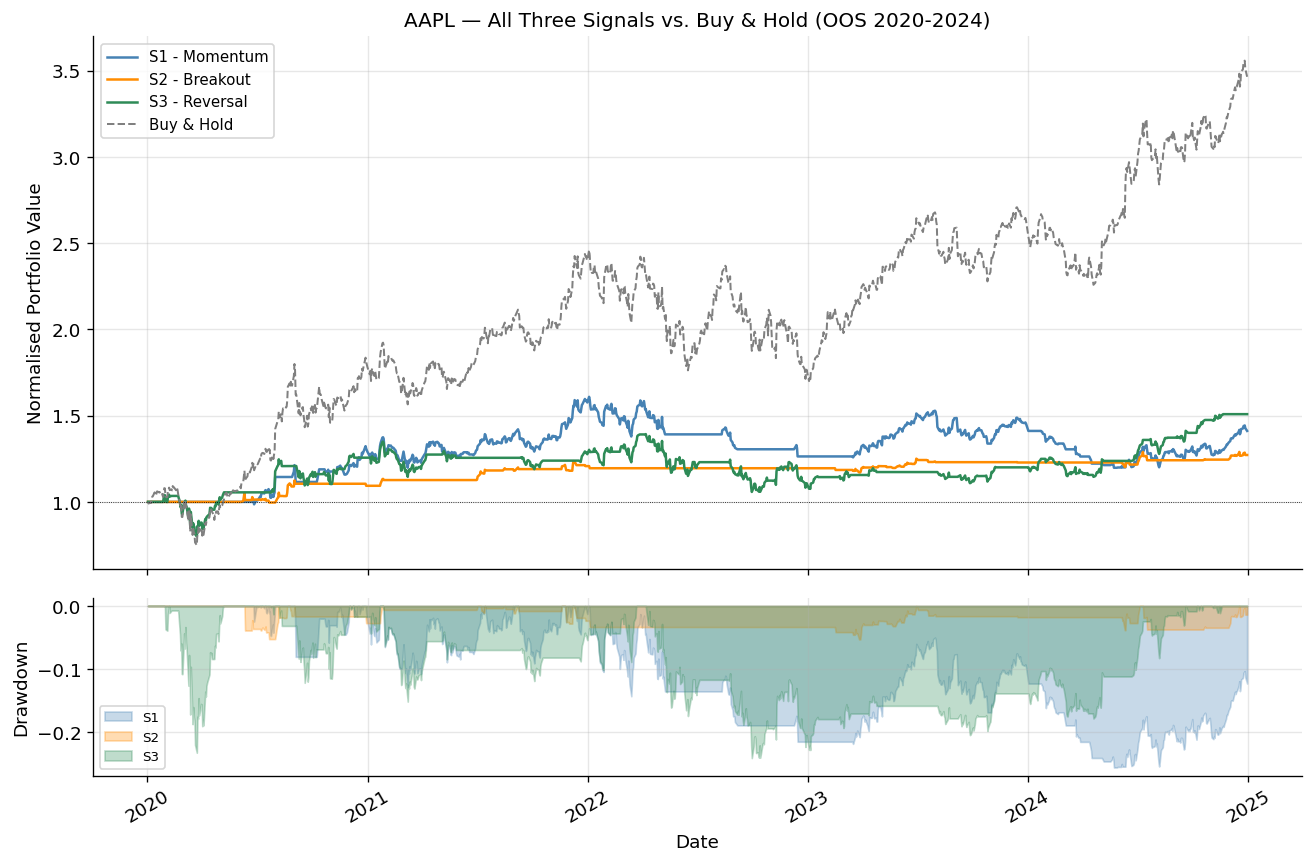

In [19]:
ticker = 'AAPL'

sig1 = module.volatility_filtered_momentum_signal(df_prices_OOS[ticker], BEST_MOM_W, BEST_VOL_W, BEST_VOL_T)
sig2 = module.trading_range_breakout_signal(df_prices_OOS[ticker], BEST_BW)
sig3 = module.short_term_reversal_signal(df_prices_OOS[ticker], BEST_LW, BEST_RT, BEST_HP)

pv1      = single_asset_backtest(df_prices_OOS[ticker], sig1)
pv2      = single_asset_backtest(df_prices_OOS[ticker], sig2)
pv3      = single_asset_backtest(df_prices_OOS[ticker], sig3)
_, pv_bh = benchmark_buy_and_hold(df_prices_OOS[ticker])

dd1   = module.compute_drawdown_series(pv1)
dd2   = module.compute_drawdown_series(pv2)
dd3   = module.compute_drawdown_series(pv3)
dates = df_prices_OOS.index

fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.plot(dates, pv1,   color='steelblue',  lw=1.5, label='S1 - Momentum')
ax1.plot(dates, pv2,   color='darkorange', lw=1.5, label='S2 - Breakout')
ax1.plot(dates, pv3,   color='seagreen',   lw=1.5, label='S3 - Reversal')
ax1.plot(dates, pv_bh, color='gray',       lw=1.2, ls='--', label='Buy & Hold')
ax1.axhline(1.0, color='black', lw=0.5, ls=':')
ax1.set_ylabel('Normalised Portfolio Value')
ax1.set_title('AAPL — All Three Signals vs. Buy & Hold (OOS 2020-2024)', fontsize=12)
ax1.legend(fontsize=9)
plt.setp(ax1.get_xticklabels(), visible=False)

ax2.fill_between(dates, dd1, 0, alpha=0.3, color='steelblue',  label='S1')
ax2.fill_between(dates, dd2, 0, alpha=0.3, color='darkorange', label='S2')
ax2.fill_between(dates, dd3, 0, alpha=0.3, color='seagreen',   label='S3')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('s4_combined_AAPL.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.4 Combined Portfolio Value Plot — AAPL — Interpretation

This plot puts all three signals and buy-and-hold on the same axes for AAPL,
with a drawdown panel below. It is the most intuitive single visual for a presentation.

**Top panel — portfolio value:**
All three strategy lines (blue, orange, green) stay well below the grey B&H line.
This is expected and should not be presented as a failure — it reflects that 2020–2024
was an exceptional bull market where passive investing was very hard to beat in
absolute terms. The important thing to point to is the *smoothness* of the strategy
lines compared to the jagged grey line.

The grey B&H line crashes sharply in early 2022 (AAPL's -30% drawdown) and then
recovers. All three strategy lines barely move during this period — they are sitting
in cash. This is the visual proof of downside protection.

**Bottom panel — drawdown:**
The three coloured shaded regions show how far below their previous peaks each
strategy is at any given time. Compare this to what B&H's drawdown would look like
if plotted: it would show a deep trough in 2022 reaching -30%.

Signal 2 (orange) has the shallowest shading — almost invisible. It is the most
protective strategy.
Signal 1 (blue) and Signal 3 (green) show moderate drawdown shading, concentrated
in the 2022 period when even cautious strategies felt some pain.

**The sentence to say when presenting this plot:**
*"All three strategies sacrifice some absolute return compared to buy-and-hold, but
they do so in exchange for dramatically smoother portfolio paths and smaller drawdowns.
For an institutional investor or anyone who cannot stomach a 30% loss, this trade-off
is not only acceptable — it is the entire point of systematic signal-based investing."*

---
## Section 5 — Summary and Parameter Recommendations

The table below consolidates the selected parameters for each signal and summarises their average out-of-sample performance across all six evaluation stocks.


In [20]:
print('=== Final Selected Parameters ===\n')
print(f'Signal 1 - Volatility-Filtered Momentum')
print(f'  momentum_window      = {BEST_MOM_W}  (~{BEST_MOM_W//21} months)')
print(f'  volatility_window    = {BEST_VOL_W}  (~{BEST_VOL_W//21} months)')
print(f'  volatility_threshold = {BEST_VOL_T}')
print()
print(f'Signal 2 - Trading-Range Breakout')
print(f'  breakout_window      = {BEST_BW} days')
print()
print(f'Signal 3 - Short-Term Reversal')
print(f'  lookback_window      = {BEST_LW} days')
print(f'  return_threshold     = {BEST_RT}')
print(f'  holding_period       = {BEST_HP} days')

# Average OOS stats per signal
summary = []
for label in ['S1-Mom', 'S2-Brk', 'S3-Rev', 'B&H']:
    subset = df_compare[df_compare['Strategy'].str.startswith(label)]
    summary.append({
        'Signal':          label,
        'Avg OOS Sharpe':  f"{subset['Sharpe Ratio'].astype(float).mean():.2f}",
        'Avg OOS Ann Ret': f"{subset['Ann. Return'].astype(float).mean()*100:.1f}%",
        'Avg OOS Max DD':  f"{subset['Max Drawdown'].astype(float).mean()*100:.1f}%",
        'Avg Win Rate':    f"{subset['Win Rate'].astype(float).mean()*100:.1f}%",
    })

print('\n=== Out-of-Sample Performance Summary (average across 6 stocks) ===\n')
print(pd.DataFrame(summary).to_string(index=False))


=== Final Selected Parameters ===

Signal 1 - Volatility-Filtered Momentum
  momentum_window      = 120  (~5 months)
  volatility_window    = 20  (~0 months)
  volatility_threshold = 0.025

Signal 2 - Trading-Range Breakout
  breakout_window      = 100 days

Signal 3 - Short-Term Reversal
  lookback_window      = 5 days
  return_threshold     = -0.03
  holding_period       = 10 days

=== Out-of-Sample Performance Summary (average across 6 stocks) ===

Signal Avg OOS Sharpe Avg OOS Ann Ret Avg OOS Max DD Avg Win Rate
S1-Mom           0.92           17.5%         -18.8%        29.6%
S2-Brk           0.23            2.4%         -11.8%         5.2%
S3-Rev           0.59           15.8%         -39.9%        31.4%
   B&H           0.89           35.2%         -52.0%        53.3%
